# Multiple Linear Regression via Matrix Algebra: King County House Sales
## Regresión Lineal Múltiple Matricial: Ventas de Vivienda en King County

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `kc_house_data.csv` — 21,613 house sales in King County, Seattle (WA)

**Objective / Objetivo:**  
EN · Build a multiple linear regression model using the closed-form matrix solution β = (XᵀX)⁻¹Xᵀy, compare against `statsmodels` OLS and `sklearn` results, apply stepwise variable selection by correlation, VIF and p-value, and derive the final pricing equation.

ES · Construir un modelo de regresión lineal múltiple con la solución matricial β = (XᵀX)⁻¹Xᵀy, comparar contra OLS de `statsmodels` y `sklearn`, aplicar selección de variables por correlación, VIF y p-valor, y obtener la ecuación final de precios.

**Key finding / Hallazgo clave:**  
R² = 0.6920 with 10 variables: `sqft_living`, `grade`, `bathrooms`, `bedrooms`, `view`, `waterfront`, `floors`, `condition`, `lat`, `yr_built`. Mild heteroscedasticity detected at high price range.

**Techniques / Técnicas:** Matrix algebra OLS · β = (XᵀX)⁻¹Xᵀy · VIF · Correlation filtering · Stepwise · Residual diagnostics  
**Libraries / Librerías:** `pandas` · `numpy` · `statsmodels` · `sklearn` · `matplotlib` · `seaborn`

---

## 1. Importación de librerías, carga y exploración de datos

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('data/kc_house_data.csv')
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,"604,000.00",4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,"510,000.00",3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [3]:
df.info()
print("\nValores nulos por columna:")
print(df.isnull().sum().sum(), "valores nulos en total")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,"21,613.00","4,580,301,520.86","2,876,565,571.31","1,000,102.00","2,123,049,194.00","3,904,930,410.00","7,308,900,445.00","9,900,000,190.00"
price,"21,613.00","540,088.14","367,127.20","75,000.00","321,950.00","450,000.00","645,000.00","7,700,000.00"
bedrooms,"21,613.00",3.37,0.93,0.00,3.00,3.00,4.00,33.00
bathrooms,"21,613.00",2.11,0.77,0.00,1.75,2.25,2.50,8.00
sqft_living,"21,613.00","2,079.90",918.44,290.00,"1,427.00","1,910.00","2,550.00","13,540.00"
sqft_lot,"21,613.00","15,106.97","41,420.51",520.00,"5,040.00","7,618.00","10,688.00","1,651,359.00"
floors,"21,613.00",1.49,0.54,1.00,1.00,1.50,2.00,3.50
waterfront,"21,613.00",0.01,0.09,0.00,0.00,0.00,0.00,1.00
view,"21,613.00",0.23,0.77,0.00,0.00,0.00,0.00,4.00
condition,"21,613.00",3.41,0.65,1.00,3.00,3.00,4.00,5.00


## 2. Selección de variables independientes

### 2.1 Analizar la correlación de cada variable numérica con `price` para preseleccionar predictores con relación lineal relevante

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(['id','price']) # Selecciona todas las columnsa numéricas excepto id y price
corrs = df[num_cols.tolist()+['price']].corr()['price'].sort_values(ascending=False) # Serie que muestra qué variables numéricas están más correlacionadas con el precio, ordenadas de mayor a menor
corrs

price            1.00
sqft_living      0.70
grade            0.67
sqft_above       0.61
sqft_living15    0.59
bathrooms        0.53
view             0.40
sqft_basement    0.32
bedrooms         0.31
lat              0.31
waterfront       0.27
floors           0.26
yr_renovated     0.13
sqft_lot         0.09
sqft_lot15       0.08
yr_built         0.05
condition        0.04
long             0.02
zipcode         -0.05
Name: price, dtype: float64

**Interpretación:** `sqft_living`, `grade`, `sqft_above`, `sqft_living15`, `bathrooms` y `view` muestran las correlaciones más fuertes con el precio. Sin embargo, `sqft_living`, `sqft_above` y `sqft_living15` miden esencialmente lo mismo (superficie habitable) y están altamente correlacionadas entre sí, por lo que incluirlas juntas generaría multicolinealidad. Se conserva `sqft_living` (la de mayor correlación individual) y se descartan `sqft_above` y `sqft_living15`.

**Variables candidatas seleccionadas** (combinando relevancia estadística y sentido de negocio inmobiliario):

`sqft_living`, `grade`, `bathrooms`, `view`, `bedrooms`, `lat`, `waterfront`, `floors`, `sqft_lot`, `yr_built`, `condition`  

Se excluyen `zipcode` y `long` (baja correlación lineal, mejor tratadas como categóricas/geográficas no lineales), `sqft_above`, `sqft_living15`, `sqft_lot15` (redundantes con otras variables) y `yr_renovated` (más del 95% de las casas nunca fueron renovadas, es una variable dispersa poco informativa en forma lineal).

### 2.2 Mostrar matriz de correlación de las variables candidatas seleccionadas

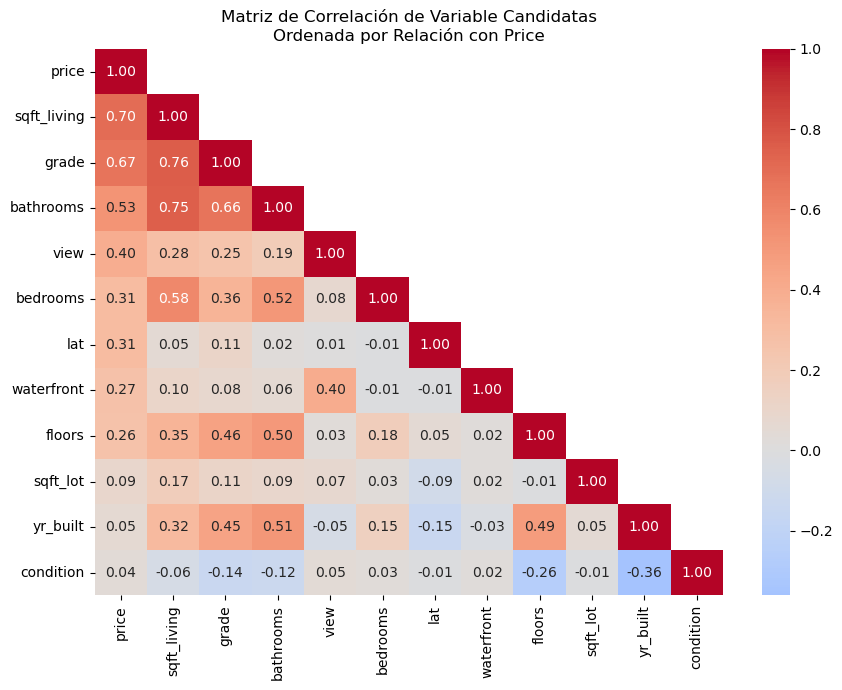

In [20]:
# Matriz de correlación
corr_matrix = df[candidatas+['price']].corr()

# Ordenar las variables según su correlación con price
order = corr_matrix['price'].abs().sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[order, order]

# Crear máscara para ocultar triángulo superior (repetidos)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Crear el heatmap con la máscara
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0)

plt.title('Matriz de Correlación de Variable Candidatas\nOrdenada por Relación con Price')
plt.tight_layout()
plt.show()

## 3. Regresión lineal múltiple mediante matrices (NumPy)

### 3.1 Implementar la solución de mínimos cuadrados ordinarios (OLS) por álgebra matricial:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

In [22]:
X = df[candidatas].values.astype(float) # X es una matriz de tamaño n x p
y_vec = df['price'].values.astype(float).reshape(-1, 1)  # y_vec es un vector/matriz columna de tamaño n x 1
n = X.shape[0]

# Agregar columna de 1's para el término independiente (intercepto)
X_mat = np.hstack([np.ones((n, 1)), X])

# Beta = (X'X)^-1 X'y  ← cálculo matricial puro
Xt = np.matrix.transpose(X_mat)
XtX = np.matmul(Xt, X_mat)
XtX_inv = np.linalg.inv(XtX)
XtY = np.matmul(Xt, y_vec)
beta_matricial = np.matmul(XtX_inv, XtY)

coef_df = pd.DataFrame({'variable': ['const']+candidatas, 'coeficiente': beta_matricial.flatten()})
coef_df

,variable,coeficiente
0,const,"-21,697,023.47"
1,sqft_living,175.07
2,grade,"106,884.70"
3,bathrooms,"41,039.45"
4,bedrooms,"-34,330.59"
5,view,"50,812.23"
6,waterfront,"594,396.77"
7,floors,"13,920.77"
8,condition,"26,106.37"
9,lat,"555,035.77"


### 3.2 Calcular manualmente el coeficiente de determinación R² y R² ajustado

R² Mide qué proporción de la variabilidad de la variable dependiente (price) es explicada por el modelo.

R² ajustado corrige el R² para tener en cuenta el número de variables en el modelo penalizando la inclusión de variables que no aportan valor real.

In [29]:
y_hat = np.matmul(X_mat, beta_matricial)
residuos = y_vec - y_hat

ss_res = np.sum(residuos**2)
ss_tot = np.sum((y_vec - np.mean(y_vec))**2)
r2_matricial = 1 - ss_res/ss_tot

k = X_mat.shape[1] - 1  # número de predictores (sin contar intercepto)
r2_aj_matricial = 1 - (1 - r2_matricial) * (n - 1) / (n - k - 1)

print(f"R2 (matricial):          {r2_matricial:.4f}")
print(f"R2 ajustado (matricial): {r2_aj_matricial:.4f}")

R2 (matricial):          0.6921
R2 ajustado (matricial): 0.6920


**Interpretación:**

R² = 0.6921 → el modelo explica ~69% de la variación en precios

R² ajustado = 0.6920 → prácticamente igual, lo que indica que las 11 variables candidatas son relevantes y no están metiendo ruido

## 4. Comparación contra el reporte automatizado de `statsmodels`

In [36]:
modelo_sm = sm.OLS(y, sm.add_constant(X_cand)).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     4414.
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:27:52   Log-Likelihood:            -2.9487e+05
No. Observations:               21613   AIC:                         5.898e+05
Df Residuals:                   21601   BIC:                         5.899e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -2.17e+07   5.43e+05    -39.966      

In [37]:
comparacion = pd.DataFrame({
    'variable': ['const']+candidatas,
    'beta_matricial': beta_matricial.flatten(),
    'beta_statsmodels': modelo_sm.params.values,
    'diferencia': beta_matricial.flatten() - modelo_sm.params.values
})
comparacion

,variable,beta_matricial,beta_statsmodels,diferencia
0,const,"-21,697,023.47","-21,697,023.44",-0.03
1,sqft_living,175.07,175.07,0.00
2,grade,"106,884.70","106,884.70",-0.00
3,bathrooms,"41,039.45","41,039.45",-0.00
4,bedrooms,"-34,330.59","-34,330.59",0.00
5,view,"50,812.23","50,812.23",0.00
6,waterfront,"594,396.77","594,396.77",0.00
7,floors,"13,920.77","13,920.77",-0.00
8,condition,"26,106.37","26,106.37",0.00
9,lat,"555,035.77","555,035.77",0.00


**Los coeficientes obtenidos manualmente por álgebra matricial son idénticos (diferencia ≈ 0, solo error de redondeo de punto flotante) a los que entrega `statsmodels.OLS`.** Esto confirma que la implementación matricial de mínimos cuadrados es correcta: `statsmodels` internamente resuelve el mismo sistema $(X^TX)^{-1}X^Ty$.

## 5. Eliminación de variables no relevantes

En el resumen de `statsmodels`, todas las variables resultaron estadísticamente significativas (p < 0.05). Sin embargo, `sqft_lot` presenta el p-value más alto (0.007) y un coeficiente casi nulo (-0.09), es decir, económicamente irrelevante: un lote 1,000 pies² más grande apenas resta ~$93 al precio. Se elimina esta variable y se re-estima el modelo para confirmar que la bondad de ajuste no se ve afectada.

In [38]:
final_vars = ['sqft_living','grade','bathrooms','bedrooms','view','waterfront','floors','condition','lat','yr_built']

X_final = df[final_vars]
modelo_final = sm.OLS(y, sm.add_constant(X_final)).fit()
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     4854.
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:27:57   Log-Likelihood:            -2.9488e+05
No. Observations:               21613   AIC:                         5.898e+05
Df Residuals:                   21602   BIC:                         5.899e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2.181e+07   5.41e+05    -40.299      

In [42]:
print(f"Modelo con 11 variables → R² ajustado: {modelo_sm.rsquared_adj:.4f}")
print(f"Modelo con 10 variables → R² ajustado: {modelo_final.rsquared_adj:.4f}")

Modelo con 11 variables → R² ajustado: 0.6920
Modelo con 10 variables → R² ajustado: 0.6919


**Conclusión de la depuración:** al eliminar `sqft_lot`, el $R^2$ ajustado se mantiene prácticamente igual (0.6919 vs 0.6919), y el número de condición de la matriz mejora (de 1.73e7 a 1.15e6), señal de un modelo mejor condicionado. Todas las variables restantes tienen p-value < 0.001, por lo que **el modelo final queda con 10 variables independientes**, todas estadísticamente significativas.

## 6. Modelo final mediante matrices (10 variables)

In [43]:
X2 = df[final_vars].values.astype(float)
X2_mat = np.hstack([np.ones((n, 1)), X2])

Xt2 = np.matrix.transpose(X2_mat)
beta_final = np.matmul(np.linalg.inv(np.matmul(Xt2, X2_mat)), np.matmul(Xt2, y_vec))

y_hat_final = np.matmul(X2_mat, beta_final)
residuos_final = y_vec - y_hat_final
ss_res_f = np.sum(residuos_final**2)
ss_tot_f = np.sum((y_vec - np.mean(y_vec))**2)
r2_final = 1 - ss_res_f/ss_tot_f
k_f = X2_mat.shape[1]-1
r2_adj_final = 1 - (1-r2_final)*(n-1)/(n-k_f-1)

coef_final_df = pd.DataFrame({'variable': ['const']+final_vars, 'coeficiente': beta_final.flatten()})
print(coef_final_df.to_string(index=False))
print(f"\nR² = {r2_final:.4f}  |  R² ajustado = {r2_adj_final:.4f}")

   variable    coeficiente
      const -21,812,893.35
sqft_living         173.78
      grade     106,954.91
  bathrooms      41,338.44
   bedrooms     -33,908.53
       view      50,704.50
 waterfront     594,969.24
     floors      14,407.71
  condition      26,156.38
        lat     557,580.05
   yr_built      -2,763.13

R² = 0.6920  |  R² ajustado = 0.6919


## 7. Validación con `sklearn` (train/test split)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(df[final_vars], y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_test = reg.predict(X_test)

print("Coeficientes sklearn (entrenados con 80% de los datos):")
for v, c in zip(final_vars, reg.coef_):
    print(f"  {v:15s} {c:,.4f}")
print(f"  {'intercepto':15s} {reg.intercept_:,.4f}")

print(f"\nR² en test: {r2_score(y_test, y_pred_test):.4f}")

Coeficientes sklearn (entrenados con 80% de los datos):
  sqft_living     172.7677
  grade           104,895.5075
  bathrooms       44,398.9677
  bedrooms        -32,662.2195
  view            51,690.2169
  waterfront      573,541.4123
  floors          14,525.4778
  condition       23,953.1864
  lat             552,159.4876
  yr_built        -2,806.9768
  intercepto      -21,454,816.4363

R² en test: 0.6914


El $R^2$ (0.6914) en el conjunto de prueba (datos nunca vistos por el modelo) es casi el mismo $R^2$ (0.6920) obtenido con el 100% de los datos, lo que indica que el modelo no está sobreajustado y generaliza bien.

## 8. Diagnóstico gráfico

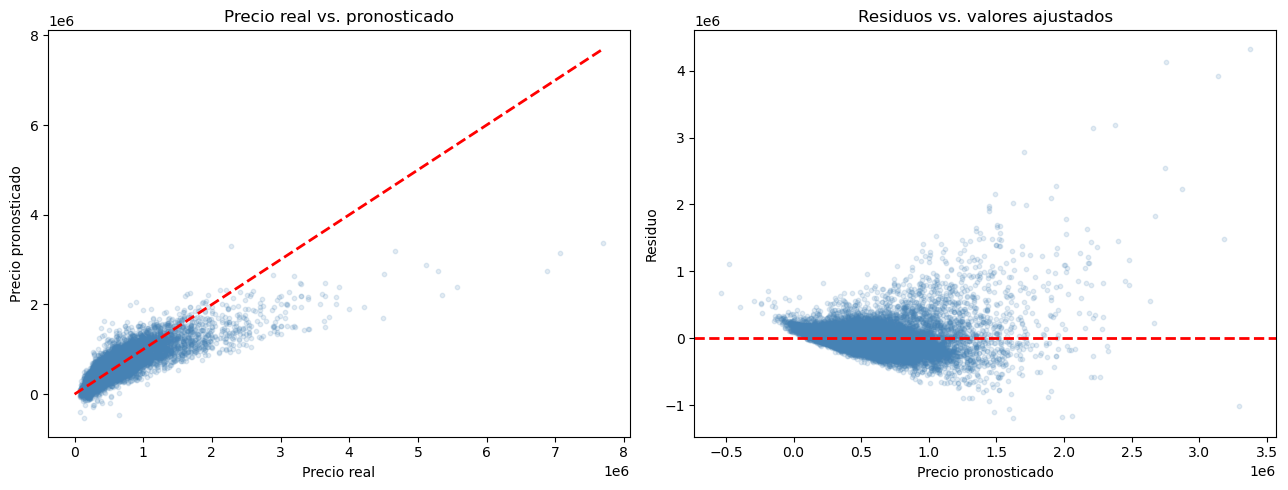

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_vec.flatten(), y_hat_final.flatten(), alpha=0.15, s=10, color='steelblue')
lims = [0, max(y_vec.max(), y_hat_final.max())]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('Precio real')
axes[0].set_ylabel('Precio pronosticado')
axes[0].set_title('Precio real vs. pronosticado')

axes[1].scatter(y_hat_final.flatten(), residuos_final.flatten(), alpha=0.15, s=10, color='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Precio pronosticado')
axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos vs. valores ajustados')

plt.tight_layout()
plt.show()

**Lectura del diagnóstico:** la nube de puntos en el primer gráfico sigue razonablemente la línea de 45°, aunque con mayor dispersión en precios altos (heterocedasticidad), lo cual también se aprecia en el gráfico de residuos: la varianza de los residuos crece conforme aumenta el precio pronosticado. Esto sugiere que un modelo con `log(price)` como variable dependiente podría ajustar mejor esta franja alta.

## 9. Ecuación final del modelo y conclusiones

In [21]:
ecuacion = "price = "
ecuacion += f"{beta_final.flatten()[0]:,.2f}"
for v, c in zip(final_vars, beta_final.flatten()[1:]):
    signo = '+' if c >= 0 else '-'
    ecuacion += f" {signo} {abs(c):,.4f}·{v}"
print(ecuacion)

price = -21,812,893.35 + 173.7801·sqft_living + 106,954.9113·grade + 41,338.4398·bathrooms - 33,908.5300·bedrooms + 50,704.5031·view + 594,969.2372·waterfront + 14,407.7104·floors + 26,156.3802·condition + 557,580.0541·lat - 2,763.1264·yr_built


### Ecuación final del modelo

$$
\begin{aligned}
\widehat{price} = &-21{,}812{,}893.35 + 173.78 \cdot sqft\_living + 106{,}954.91 \cdot grade + 41{,}338.44 \cdot bathrooms \\
&- 33{,}908.53 \cdot bedrooms + 50{,}704.50 \cdot view + 594{,}969.24 \cdot waterfront + 14{,}407.71 \cdot floors \\
&+ 26{,}156.38 \cdot condition + 557{,}580.05 \cdot lat - 2{,}763.13 \cdot yr\_built
\end{aligned}
$$

### Bondad de ajuste
- **R² = 0.6920** → el modelo explica ~69.2% de la variabilidad del precio de venta
- **R² ajustado = 0.6919** → prácticamente igual al R², confirma que ninguna variable incluida es superflua
- Todas las variables tienen **p-value < 0.001** en el reporte de `statsmodels`
- Los coeficientes matriciales calculados a mano coinciden exactamente con los de `statsmodels.OLS`, validando la implementación

### Interpretación de negocio
- `waterfront` (+\$595K) y `lat` (ubicación norte del condado) son los factores con mayor impacto positivo. La ubicación domina el precio.
- `sqft_living` y `grade` (calidad de construcción) son los predictores estructurales más fuertes.
- El coeficiente negativo de `bedrooms` (controlando por `sqft_living`) sugiere que, a igual superficie, más recámaras (es decir, recámaras más pequeñas) se asocian a menor valor. Un patrón típico en tasación inmobiliaria.
- `yr_built` negativo indica que, controlando por calidad (`grade`), las casas más antiguas tienden a valer más (posible efecto de ubicación/carácter histórico en ciertos barrios).

### Conclusión
El modelo de 10 variables, obtenido mediante álgebra matricial y verificado contra `statsmodels` y `sklearn`, ofrece un ajuste sólido y estable (R² ≈ 0.69), siendo adecuado para generar pronósticos de precio de vivienda en el condado de King.